
=== NOR Gate using Single Layer Perceptron ===
Weights: [[-0.2 -0.2 -0.2]]
Bias: [0.1]

Predictions: [1 0 0 0 0 0 0 0]

Accuracy: 1.0

Confusion Matrix:
 [[7 0]
 [0 1]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00         1

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8



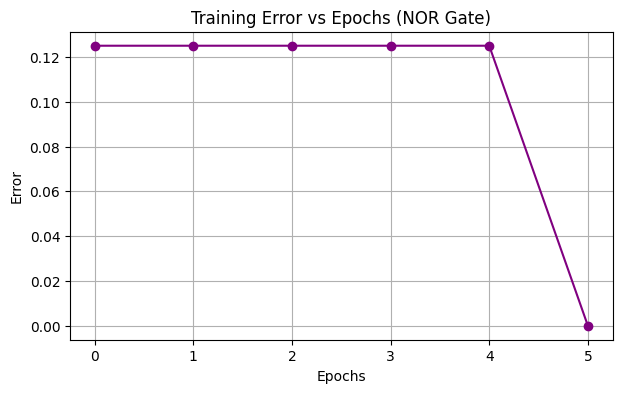

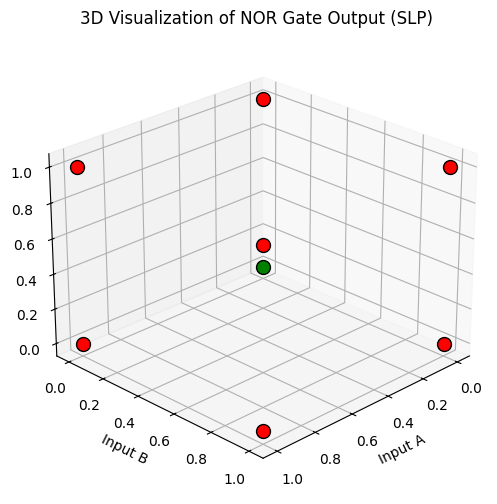

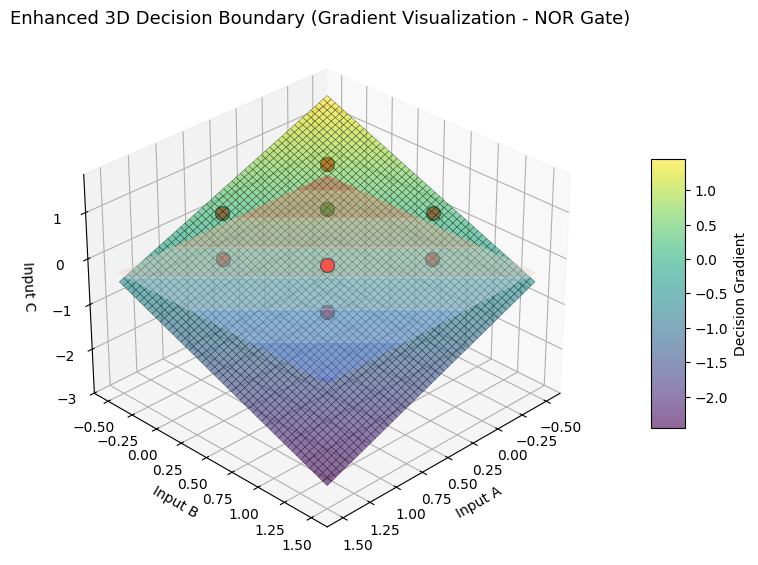

In [1]:
# nor_gate_slp.py
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from mpl_toolkits.mplot3d import Axes3D

# ----------------------------
# 1. Define the dataset (NOR gate for 3 variables)
# ----------------------------
# Inputs (A, B, C) - all possible combinations
X = np.array([[0, 0, 0],
              [0, 0, 1],
              [0, 1, 0],
              [0, 1, 1],
              [1, 0, 0],
              [1, 0, 1],
              [1, 1, 0],
              [1, 1, 1]])

# Output (A NOR B NOR C) = NOT (A OR B OR C)
y = np.array([1, 0, 0, 0, 0, 0, 0, 0])

# ----------------------------
# 2. Create and train the SLP model
# ----------------------------
model = Perceptron(max_iter=100, eta0=0.1, random_state=42)
errors = []

# Manual training loop to track error per epoch
for _ in range(100):
    model.partial_fit(X, y, classes=np.unique(y))
    y_pred = model.predict(X)
    err = np.mean(y_pred != y)
    errors.append(err)
    if err == 0:
        break

# ----------------------------
# 3. Predictions and metrics
# ----------------------------
y_pred = model.predict(X)
acc = accuracy_score(y, y_pred)
cm = confusion_matrix(y, y_pred)
report = classification_report(y, y_pred)

# ----------------------------
# 4. Display results
# ----------------------------
print("\n=== NOR Gate using Single Layer Perceptron ===")
print("Weights:", model.coef_)
print("Bias:", model.intercept_)
print("\nPredictions:", y_pred)
print("\nAccuracy:", acc)
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n", report)

# ----------------------------
# 5. Plot line chart (Error vs Epochs)
# ----------------------------
plt.figure(figsize=(7, 4))
plt.plot(errors, marker='o', color='purple')
plt.title("Training Error vs Epochs (NOR Gate)")
plt.xlabel("Epochs")
plt.ylabel("Error")
plt.grid(True)
plt.show()

# ----------------------------
# 6. 3D Visualization (Data points and output classification)
# ----------------------------
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

for xi, yi in zip(X, y_pred):
    color = 'green' if yi == 1 else 'red'
    ax.scatter(xi[0], xi[1], xi[2], c=color, s=100, edgecolor='k')

ax.set_title("3D Visualization of NOR Gate Output (SLP)")
ax.set_xlabel("Input A")
ax.set_ylabel("Input B")
ax.set_zlabel("Input C")
ax.view_init(25, 45)

plt.show()

# ----------------------------
# 7. Enhanced 3D Visualization with Gradient Decision Boundary
# ----------------------------
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

# Scatter classified points
for xi, yi in zip(X, y_pred):
    color = 'green' if yi == 1 else 'red'
    ax.scatter(xi[0], xi[1], xi[2], c=color, s=100, edgecolor='k', depthshade=True)

# Create high-resolution mesh grid
x_range = np.linspace(-0.5, 1.5, 50)
y_range = np.linspace(-0.5, 1.5, 50)
xx, yy = np.meshgrid(x_range, y_range)

# Extract weights and bias
w = model.coef_[0]
b = model.intercept_[0]

# Compute Z values from perceptron equation: w1*x + w2*y + w3*z + b = 0
# => z = -(w1*x + w2*y + b)/w3
if w[2] != 0:
    zz = -(w[0]*xx + w[1]*yy + b) / w[2]

    # Plot gradient-colored decision plane
    surf = ax.plot_surface(xx, yy, zz, cmap='viridis', alpha=0.6, edgecolor='k', linewidth=0.3)

    # Optional contour projection for visual depth
    ax.contourf(xx, yy, zz, zdir='z', offset=-0.3, cmap='coolwarm', alpha=0.4)
    fig.colorbar(surf, shrink=0.5, aspect=8, pad=0.1, label='Decision Gradient')
else:
    print("Cannot plot plane: weight for C is zero (w3 = 0)")

ax.set_title("Enhanced 3D Decision Boundary (Gradient Visualization - NOR Gate)", fontsize=13)
ax.set_xlabel("Input A")
ax.set_ylabel("Input B")
ax.set_zlabel("Input C")
ax.view_init(30, 45)
plt.show()

In [2]:
import joblib
joblib.dump(model, "nor_gate_slp.pkl")

['nor_gate_slp.pkl']